## 0. 导入必要函数库

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import joblib
import textwrap
import os
import re

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)

## 1. 模型训练

### 1.1 模型预定义

在这里我们选择了8种模型进行比较：岭回归 Ridge，默认（L2 正则化） Logistic 回归，L1 正则化 Logistic 回归，弹性网络 Logistic 回归，支持向量机，随机森林，梯度提升机，简单的神经网络（多层感知机 MLP）

In [2]:
RANDOM_STATE = 42
models = {  "Ridge": RidgeClassifier(alpha=1.0, class_weight="balanced", random_state=RANDOM_STATE),
            "Common Logistic": LogisticRegression(penalty="l2", solver="lbfgs", C=1.0, max_iter=5000, 
                                                class_weight="balanced", random_state=RANDOM_STATE),
            "L1 Logistic": LogisticRegression(penalty="l1", solver="saga", C=1.0, max_iter=10000,
                                               class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
            "Elastic Net Logistic": LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                                                       C=1.0, max_iter=10000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
            "Linear SVM":  SVC(kernel="linear", C=1.0, class_weight="balanced", probability=False, random_state=RANDOM_STATE),
            "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_split=2, min_samples_leaf=2,
                                                    max_features="sqrt", class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
            "Gradient Boosting Classifier": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                                                        subsample=0.8, random_state=RANDOM_STATE),
            "Multilayer Perceptron": MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", solver="adam", alpha=1e-4,
                                                   learning_rate_init=1e-3, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_STATE)}

### 1.2 训练数据预清洗
需要表达矩阵与样本信息（癌症种类、样本ID等）

In [4]:
X_train = pl.read_csv("TPM_log.txt.gz", separator=",")

X_train = X_train.to_pandas()
X_train.index = X_train.iloc[:, 0]
X_train = X_train.iloc[:, 1:]

X_train = X_train.T
print(X_train.head())

                         ENSG00000000003  ENSG00000000005  ENSG00000000419  \
C3N-01842-01                    6.277955         0.299010         6.895037   
TARGET-20-PAUYRR-04A            0.305329         0.100843         5.720683   
TARGET-20-PAUYRR-09A            0.111432         0.000000         5.031413   
MMRF_1312_1_BM_CD138pos         3.351925         0.000000         5.514886   
BLGSP-71-29-00534-50A           0.000000         0.000000         6.604629   

                         ENSG00000000457  ENSG00000000460  ENSG00000000938  \
C3N-01842-01                    4.452411         4.483745         4.329088   
TARGET-20-PAUYRR-04A            3.482216         3.408413         7.110742   
TARGET-20-PAUYRR-09A            2.725218         1.996859         9.023707   
MMRF_1312_1_BM_CD138pos         2.401385         1.351119         0.333767   
BLGSP-71-29-00534-50A           3.271142         4.468336         0.200253   

                         ENSG00000000971  ENSG00000001036  ENS

In [5]:
meta = pd.read_csv("meta.csv")
print(meta.head())

meta = meta.set_index("sample_id").loc[X_train.index]
assert np.all(meta.index == X_train.index), "样本顺序不一致！"

   Unnamed: 0                sample_id         subject_id status  \
0           1             C3N-01842-01          C3N-01842  Tumor   
1           2     TARGET-20-PAUYRR-04A   TARGET-20-PAUYRR  Tumor   
2           3     TARGET-20-PAUYRR-09A   TARGET-20-PAUYRR  Tumor   
3           4  MMRF_1312_1_BM_CD138pos          MMRF_1312  Tumor   
4           5    BLGSP-71-29-00534-50A  BLGSP-71-29-00534  Tumor   

           study  
0        CPTAC-3  
1     TARGET-AML  
2     TARGET-AML  
3  MMRF-COMMPASS  
4     CGCI-BLGSP  


### 1.3 模型训练
确定输入自变量：表达矩阵，即`X_train`

输出因变量：患癌/不患癌，即`meta['status']`

In [6]:
y = (meta["status"] == "Tumor").astype(int)
groups = meta['subject_id']

为了统计模型的训练效果，我们选用三种参数：`balanced accuracy`, `f1`, `roc_auc` 

In [7]:
scorings = ["balanced_accuracy", "f1", "roc_auc"]
results = pd.DataFrame(index = models.keys(), columns = scorings)

循环对每个模型进行训练

并使用`StratifiedKFold`评估，统计各个效应值

In [ ]:
for name, model in models.items():
    print("Now processing training on", name)

    if name in ("Random Forest", "Gradient Boosting Classifier"):
        pipe = Pipeline([
        ('var_filter', VarianceThreshold(threshold=0.2)),          # 去低变异
        ('select', SelectKBest(f_classif, k=800)),                 # 选 top 800 差异基因
        ("model", model)
        ])
    else: 
        pipe = Pipeline([
        ('var_filter', VarianceThreshold(threshold=0.2)),          # 去低变异
        ('select', SelectKBest(f_classif, k=800)),                 # 选 top 800 差异基因
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y)
    joblib.dump(pipe, name + ".pkl")

    # 用 StratifiedKFold 评估（按 tissue 分组）
    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
    )

    cv_results = cross_validate(
        pipe,
        X_train,
        y,
        cv=cv,
        groups=groups,
        scoring=scorings,
        return_train_score=False,
    )

    for scoring in scorings:
        scores = cv_results[f"test_{scoring}"]
        print(f"Mean {scoring}:", scores.mean())
        print(scores)
        results.loc[name, scoring] = scores.mean()

### 1.4 结果储存与绘图

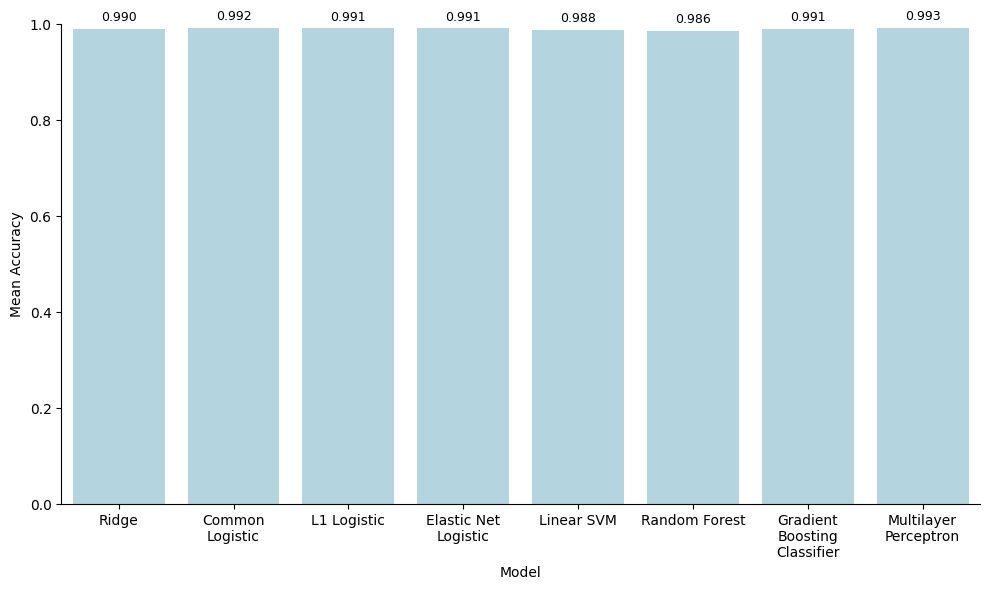

In [18]:
# results = results.astype(float)
# results.name = "mean_accuracy"
# results.to_csv("scores.csv")

results = pd.read_csv("scores.csv", index_col = 0)
plt.figure(figsize=(10, 6))
wrapped_model_names = [
    "\n".join(textwrap.wrap(model_name, width=14))
    for model_name in results.index
]
ax = sns.barplot(x=wrapped_model_names, y=results["balanced_accuracy"].values, color = "#ADD8E6")
ax.set_xlabel("Model")
ax.set_ylabel("Mean Accuracy")
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=0, ha="center")

for bar, score in zip(ax.patches, results["balanced_accuracy"].values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("model_scores_bar.png", dpi=600, bbox_inches="tight")
plt.show()

## 2 模型检测
### 2.1 加载训练的模型

In [19]:
names_model = ["Ridge", "Common Logistic", "L1 Logistic", "Elastic Net Logistic", "Linear SVM",
         "Random Forest", "Gradient Boosting Classifier", "Multilayer Perceptron"]
models = {}

for name in names_model:
    model = joblib.load(f"Models/{name}.pkl")
    models[name] = model

### 2.2 癌症组织验证数据集加载
在这里我们使用`TCGA`数据集，包含CHOL等多种癌种

注意一定**要与训练数据集同为`log2(TPM + 1)`标准化过的！**

然后定义简单的清理与数据转换函数，填充缺失 features 等

In [20]:
def fill_missing_features(X, present_features, missing_features, fill_values):
    # 从 LAML 中提取存在的特征
    X_test = X[present_features].copy()
    
    # 添加缺失特征，用相应填充值（标量）赋值
    if isinstance(fill_values, pd.Series):
        X_fill = pd.DataFrame({gene: [fill_values[gene]] * X_test.shape[0] for gene in missing_features},
        index = X_test.index)
        X_test = pd.concat([X_test, X_fill], axis=1)
    else:
        X_fill = pd.DataFrame({gene: [fill_values] * X_test.shape[0] for gene in missing_features},
                              index = X_test.index)
        X_test = pd.concat([X_test, X_fill], axis=1)
    
    return X_test

def preprocess(model, X):
    X_test = X.copy()
    X_test.columns = X_test.columns.map(lambda x: re.sub(r"\.[0-9]+$", "", x))

    # Check if the features in the validation set match those used in the model
    model_features = model.feature_names_in_   # 模型训练时使用的特征顺序
    present_features = [f for f in model_features if f in X_test.columns]
    print(f"Present features: {len(present_features) / len(model_features):.2%}")

    # If there are missing features, fill them with the mean of the training set
    missing_features = [f for f in model_features if f not in X_test.columns]
    if missing_features:
        print(f"Missing features: {len(missing_features) / len(model_features):.2%}")
        # Use the mean of the training set to fill missing features
        fill_values = X_train.mean(axis=0)
        X_test = fill_missing_features(X_test, present_features, missing_features, fill_values)

    X_test = X_test[model_features]
    print(f"Number of missing values: {X_test.isna().sum().sum()}")
    print(f"Shape of validation data: {X_test.shape}")

    # 一定注意，模型训练时用的是 log2(TPM + 1) !!!
    X_test = np.log2(X_test + 1) # Apply log2 transformation

    return X_test

### 2.3 分数计算与绘图

我们想看每个数据集的某些标准值的表现，定义计算与绘图函数：

In [21]:
def _roc_auc_input(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
        return proba[:, 1] if proba.ndim == 2 and proba.shape[1] > 1 else proba


def _score_model(model, X, y_true, scoring):
    y_pred = model.predict(X)

    scorers = {
        "accuracy": lambda: accuracy_score(y_true, y_pred),
        "balanced_accuracy": lambda: balanced_accuracy_score(y_true, y_pred),
        "f1": lambda: f1_score(y_true, y_pred),
        "f1_score": lambda: f1_score(y_true, y_pred),
        "roc_auc": lambda: roc_auc_score(y_true, _roc_auc_input(model, X)),
    }

    if scoring not in scorers:
        valid_scorings = ", ".join(scorers)
        raise ValueError(f"Unsupported scoring '{scoring}'. Choose from: {valid_scorings}")

    try:
        return scorers[scoring]()
    except ValueError:
        return np.nan


def matrix_summary(models, queues, scoring="balanced_accuracy"):
    """
    Return a score matrix for heatmap plotting.

    Parameters
    ----------
    models : dict
        {model_name: fitted_model}.
    queues : dict
        {queue_name: (X, y_true)}.
    scoring : str
        One of "accuracy", "balanced_accuracy", "f1", "f1_score", "roc_auc".

    Returns
    -------
    pandas.DataFrame
        Rows are queue names, columns are model names, values are scores.
    """
    summary = pd.DataFrame(index=list(queues), columns=list(models), dtype=float)

    for queue_name, (X, y_true) in queues.items():
        for model_name, model in models.items():
            summary.loc[queue_name, model_name] = _score_model(model, X, y_true, scoring)

    summary.index.name = "queue"
    summary.columns.name = "model"
    summary.attrs["scoring"] = scoring

    return summary

def plot_heatmap(matrix, ax=None, title=None, figsize=(10, 8), cmap="viridis", annot=True, fmt=".2f"):
    """
    Plot a heatmap of the score matrix.

    Parameters
    ----------
    matrix : pandas.DataFrame
        Score matrix with rows as queue names and columns as model names.
    ax : matplotlib.axes.Axes, optional
        Axes object to draw the heatmap onto, by default None.
    title : str, optional
        Title for the heatmap, by default None.
    figsize : tuple, optional
        Figure size, by default (10, 8).
    cmap : str, optional
        Colormap for the heatmap, by default "viridis".
    annot : bool, optional
        Whether to annotate the cells with the numeric value, by default True.
    fmt : str, optional
        String formatting code to use when adding annotations, by default ".2f".

    Returns
    -------
    matplotlib.axes.Axes
        The axes object with the heatmap.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(matrix, ax=ax, cmap=cmap, annot=annot, fmt=fmt)
    
    if title:
        ax.set_title(title)

    return ax

### 2.4 数据加载

In [22]:
files_queue = os.listdir("Validation")
files_queue = [file for file in files_queue if re.search(r"\.tsv\.gz$", file)]
queues = {}

for file in files_queue:
    print(f"Validating file {file}...")

    exp = pl.read_csv(f"Validation/{file}", separator=",")
    exp = exp.to_pandas()
    exp.index = exp.iloc[:, 0]
    exp = exp.iloc[:, 1:]
    exp = exp.T

    exp = preprocess(models[names_model[0]], exp)  # Use the first model to get the feature names

    name = file.split(".")[0]
    
    meta = pd.read_csv(f"Validation/{name}_meta.csv", sep=",")
    meta = meta.set_index("sample_id").loc[exp.index]
    y_true = (meta["status"] == "Tumor").astype(int)

    queues[name] = (exp, y_true)

Validating file TCGA-ACC.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (79, 55751)
Validating file TCGA-CHOL.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (44, 55751)
Validating file TCGA-DLBC.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (48, 55751)
Validating file TCGA-ESCA.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (198, 55751)
Validating file TCGA-KICH.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (91, 55751)
Validating file TCGA-LAML.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (151, 55751)
Validating file TCGA-LIHC.star_counts.tsv.gz...
Present features: 100.00%
Number of missing values: 0
Shape of validation data: (424, 55751)
Validating file TC

### 2.5 热图绘制

c:\Users\13774\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\13774\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\13774\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\13774\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\13774\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ra

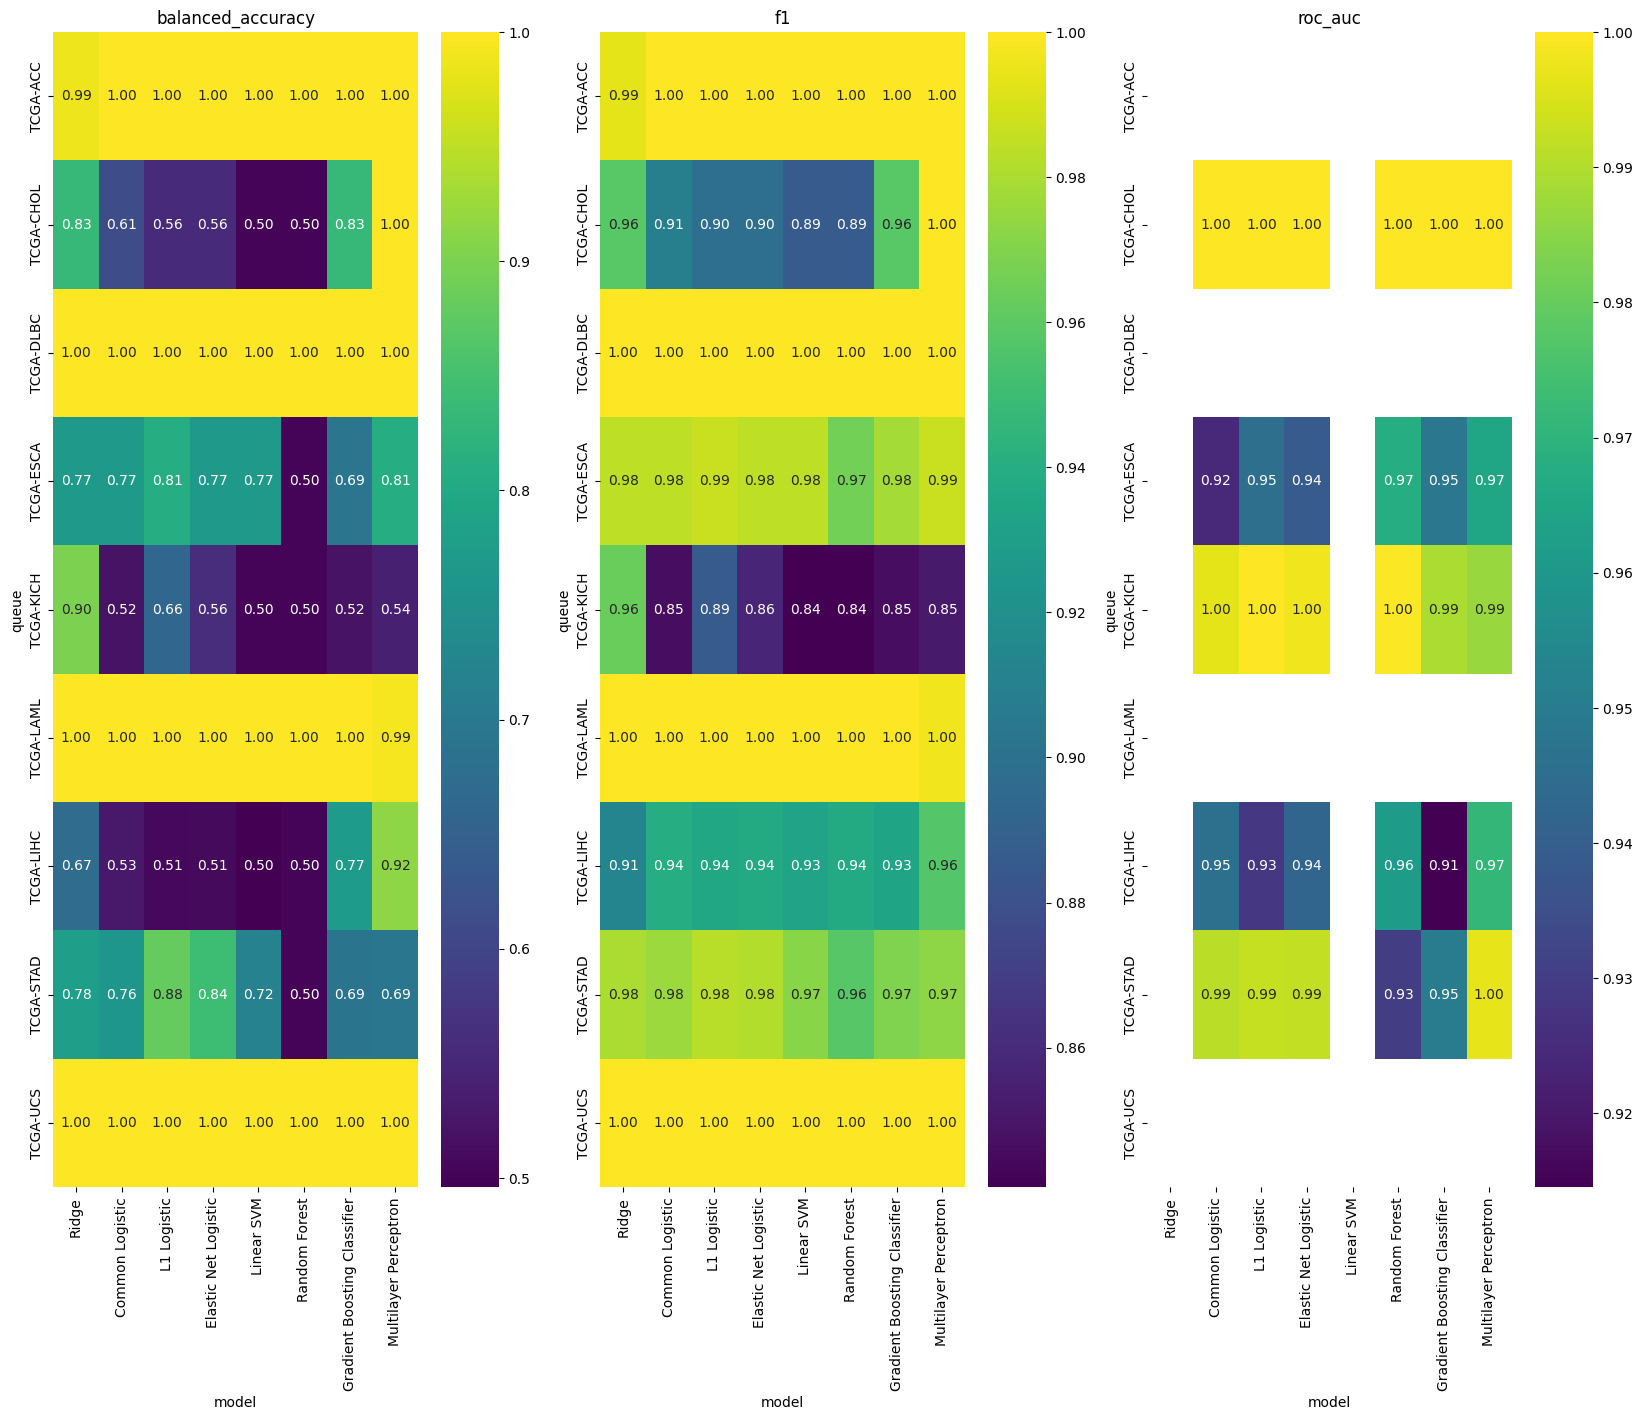

In [23]:
scorings = ["balanced_accuracy", "f1", "roc_auc"]
fig, axes = plt.subplots(1, 3, figsize = (20, 15))
for scoring, ax in zip(scorings, axes.ravel()):
    score_matrix = matrix_summary(models, queues, scoring=scoring)

    plot_heatmap(score_matrix, ax=ax, title=scoring)

plt.savefig(f"Figures/Heatmap.png", dpi=600)

## 3. 梯度提升机模型绘图

### 3.1 ROC 曲线

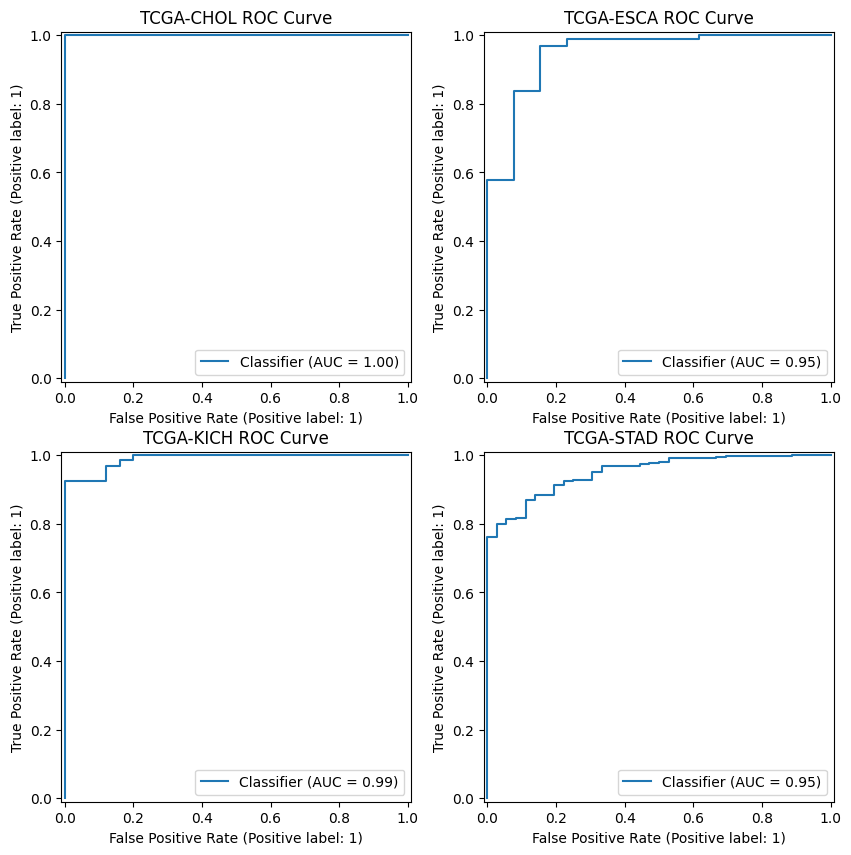

In [ ]:
model = models["Gradient Boosting Classifier"]

# 绘制 ROC 曲线
# 选择有二分类的队列
projects = ["TCGA-CHOL", "TCGA-ESCA", "TCGA-KICH", "TCGA-STAD"]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for project, ax in zip(projects, axes.ravel()):

    proba = _roc_auc_input(model, queues[project][0])

    true_label = queues[project][1]

    if(np.unique(true_label).size == 1):
        print(f"Skipping {project} as it has only one class in true labels.")
        continue

    RocCurveDisplay.from_predictions(true_label, proba, ax = ax)
    
    ax.set_title(f"{project} ROC Curve")

plt.savefig(f"Figures/ROC_Curves.png", dpi=600)

### 3.2 Feature immportances

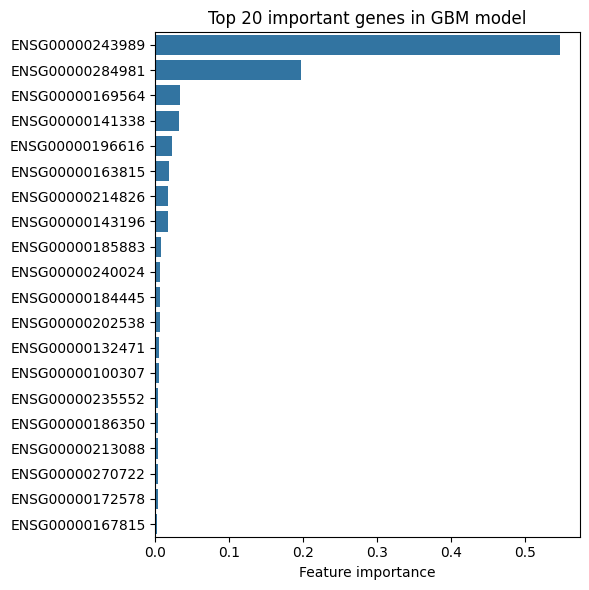

In [26]:
all_features = np.array(model.feature_names_in_)

# 经过方差过滤后的特征
var_mask = model.named_steps["var_filter"].get_support()
features_after_var = all_features[var_mask]

# 经过 SelectKBest 后的特征
select_mask = model.named_steps["select"].get_support()
selected_features = features_after_var[select_mask]

# GBM 重要性
importances = model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "gene": selected_features,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(20)

top = feat_imp.head(20)

plt.figure(figsize=(6, 6))
sns.barplot(data=top, x="importance", y="gene")

plt.xlabel("Feature importance")
plt.ylabel("")
plt.title("Top 20 important genes in GBM model")
plt.tight_layout()

plt.savefig("Figures/Feature_importances.png", dpi = 600)
plt.savefig("Figures/Feature_importances.pdf", dpi = 600)

### 3.3 SelectKBest score

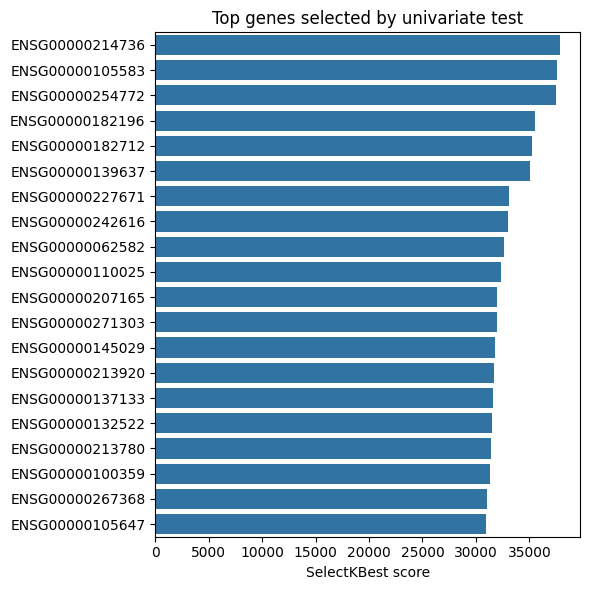

In [27]:
scores = model.named_steps["select"].scores_

kbest_score = pd.DataFrame({
    "gene": features_after_var,
    "score": scores
}).sort_values("score", ascending=False)

top_score = kbest_score.head(20)

plt.figure(figsize=(6, 6))
sns.barplot(data=top_score, x="score", y="gene")

plt.xlabel("SelectKBest score")
plt.ylabel("")
plt.title("Top genes selected by univariate test")
plt.tight_layout()

plt.savefig("Figures/SelectKBest_score.png", dpi = 600)

### 3.4 模型训练损失过程

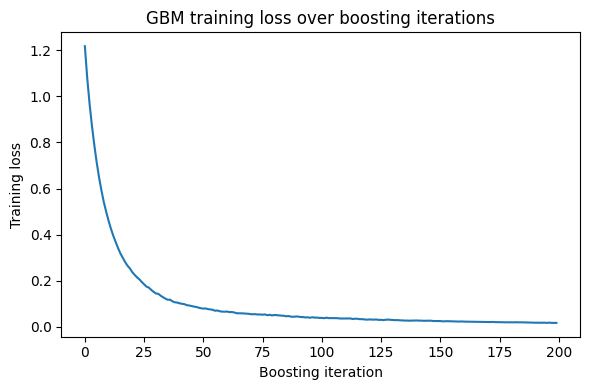

In [29]:
gbm = model.named_steps["model"]

plt.figure(figsize=(6, 4))
plt.plot(gbm.train_score_)

plt.xlabel("Boosting iteration")
plt.ylabel("Training loss")
plt.title("GBM training loss over boosting iterations")
plt.tight_layout()

plt.savefig("Figures/Training_loss.png", dpi = 600)